In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())

C:\Users\tejas\OneDrive\Desktop\DRG_project\notebooks


In [3]:
import os

print(os.path.exists(r"C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\clean_consumption.csv"))

True


In [5]:
df_clean= pd.read_csv(r"C:\Users\tejas\OneDrive\Desktop\DRG_project\data\processed\clean_consumption.csv")

In [6]:
df_clean.head()

,datetime,household_id,consumption_kwh
0,2012-05-21 11:00:00,D0000,0.081
1,2012-05-21 11:30:00,D0000,0.035
2,2012-05-21 12:00:00,D0000,0.037
3,2012-05-21 12:30:00,D0000,0.072
4,2012-05-21 13:00:00,D0000,0.329


In [7]:
df_clean["datetime"] = pd.to_datetime(
    df_clean["datetime"]
)

In [8]:
neighbourhood = (
    df_clean
    .groupby("datetime")["consumption_kwh"]
    .sum()
    .reset_index()
)

In [11]:
print(neighbourhood.head())

             datetime  total_demand_kwh
0 2011-11-23 10:00:00             0.150
1 2011-11-23 10:30:00             0.070
2 2011-11-23 11:00:00             0.033
3 2011-11-23 11:30:00             0.183
4 2011-11-23 12:00:00             0.315


In [9]:
neighbourhood.rename(
    columns={
        "consumption_kwh":"total_demand_kwh"
    },
    inplace=True
)

In [12]:
neighbourhood.head()

,datetime,total_demand_kwh
0,2011-11-23 10:00:00,0.150
1,2011-11-23 10:30:00,0.070
2,2011-11-23 11:00:00,0.033
3,2011-11-23 11:30:00,0.183
4,2011-11-23 12:00:00,0.315


In [10]:
print(neighbourhood.shape)

(39725, 2)


In [13]:
neighbourhood["total_demand_kwh"].describe()

count    39725.000000
mean       158.586525
std         97.449454
min          0.033000
25%         92.175000
50%        154.243000
75%        222.483000
max        464.916000
Name: total_demand_kwh, dtype: float64

In [14]:
neighbourhood.head()

,datetime,total_demand_kwh
0,2011-11-23 10:00:00,0.150
1,2011-11-23 10:30:00,0.070
2,2011-11-23 11:00:00,0.033
3,2011-11-23 11:30:00,0.183
4,2011-11-23 12:00:00,0.315


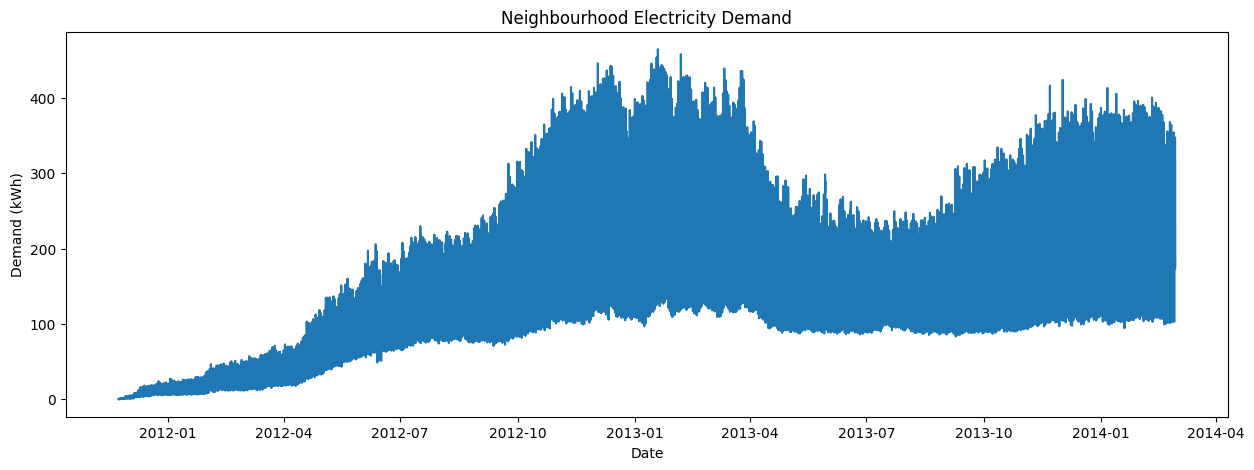

In [15]:
plt.figure(figsize=(15,5))

plt.plot(
    neighbourhood["datetime"],
    neighbourhood["total_demand_kwh"]
)

plt.title("Neighbourhood Electricity Demand")

plt.xlabel("Date")

plt.ylabel("Demand (kWh)")

plt.show()

In [17]:
neighbourhood.to_csv(
    "C:/Users/tejas/OneDrive/Desktop/DRG_project/data/processed/neighbourhood_demand.csv",
    index=False
)